In [402]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [403]:
def cargar_imagen(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        raise ValueError("archivo invalido")
    return imagen

In [404]:

def convertir_gris(imagen):
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    return gris


In [405]:

def difuminar_gris(gris):
    gris = cv2.GaussianBlur(gris, (5, 5), 0)
    return gris


In [406]:

def aplicar_treshold(gris):
    _, binaria = cv2.threshold(gris, 125, 255, cv2.THRESH_BINARY)
    return binaria


In [407]:
def detectar_cont(binaria):
    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno = max(contornos, key=cv2.contourArea)
    return contorno

In [408]:
def filtrar_silueta_superior(contorno):
    contorno = contorno.reshape(-1, 2)
    x_min_idx = np.argmin(contorno[:, 0])
    x_max_idx = np.argmax(contorno[:, 0])
    punto_x_min = contorno[x_min_idx]
    punto_x_max = contorno[x_max_idx]
    m = (punto_x_max[1] - punto_x_min[1]) / (punto_x_max[0] - punto_x_min[0])
    b = punto_x_min[1] - m * punto_x_min[0]
    contorno_superior = []
    for punto in contorno:
        if punto[1] < m * punto[0] + b:
            contorno_superior.append(punto)
    return np.array(contorno_superior, dtype=np.int32)

In [409]:
def extrapolar_puntos(contorno, num_puntos=50):
    contorno = contorno.reshape(-1, 2)
    longitud = cv2.arcLength(contorno, True)
    distancia = longitud / num_puntos
    puntos_extrapolados = []
    distancia_acumulada = 0
    for i in range(len(contorno)):
        if distancia_acumulada >= distancia:
            puntos_extrapolados.append(contorno[i])
            distancia_acumulada = 0

        else:
            if i > 0:
                distancia_acumulada += np.linalg.norm(contorno[i] - contorno[i - 1])
    if len(puntos_extrapolados) > num_puntos:
        puntos_extrapolados = puntos_extrapolados[:num_puntos]
    return np.array(puntos_extrapolados)

In [410]:


def dibujar_contorno(imagen, contorno, puntos_extrapolados):
    cv2.drawContours(imagen, [contorno], -1, (0, 255, 0), 2)
    for punto in puntos_extrapolados:
        cv2.circle(imagen, tuple(punto), 5, (0, 0, 255), -1)
    return imagen


In [411]:
def solve_tridiagonal(a, b, c, d):
    n = len(d)
    w = np.zeros(n-1)
    g = np.zeros(n)
    p = np.zeros(n)

    w[0] = c[0] / b[0]
    g[0] = d[0] / b[0]

    for i in range(1, n-1):
        denom = b[i] - a[i-1] * w[i-1]
        w[i] = c[i] / denom
        g[i] = (d[i] - a[i-1] * g[i-1]) / denom

    g[-1] = (d[-1] - a[-2] * g[-2]) / (b[-1] - a[-2] * w[-2])

    p[-1] = g[-1]
    for i in range(n-2, -1, -1):
        p[i] = g[i] - w[i] * p[i+1]

    return p

In [412]:
def evaluate_spline(x, y, m, h, z):
    i = np.searchsorted(x, z) - 1
    i = np.clip(i, 0, n-1)
    h_i = h[i]
    A = (x[i+1] - z) / h_i
    B = (z - x[i]) / h_i
    C = (A**3 - A) * h_i**2 / 6
    D = (B**3 - B) * h_i**2 / 6
    return A * y[i] + B * y[i+1] + C * m[i] + D * m[i+1]

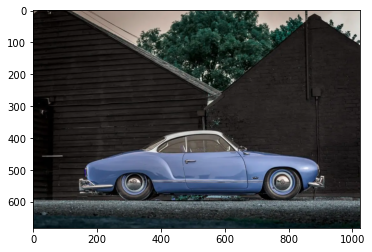

In [413]:

ruta_imagen = 'imagen.jpg'
imagen = cargar_imagen(ruta_imagen)
plt.imshow(imagen)


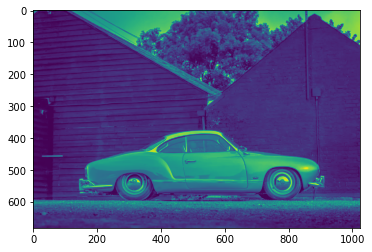

In [414]:
gris = convertir_gris(imagen)
plt.imshow(gris)
plt.show()

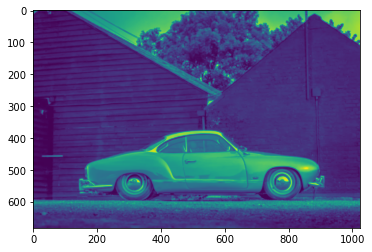

In [415]:
gris = difuminar_gris(gris)
plt.imshow(gris)

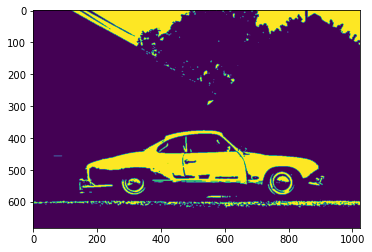

In [416]:
binario = aplicar_treshold(gris)
plt.imshow(binario)

In [417]:
contorno = detectar_cont(binario)
contorno_superior = filtrar_silueta_superior(contorno)
puntos_extrapolados = extrapolar_puntos(contorno_superior, num_puntos=50)


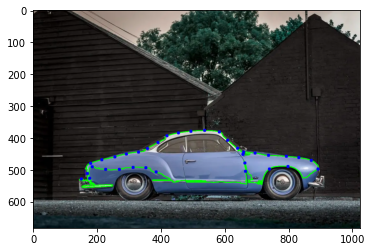

In [418]:
imagen_resultante = dibujar_contorno(imagen, contorno, puntos_extrapolados)
plt.imshow(imagen_resultante)

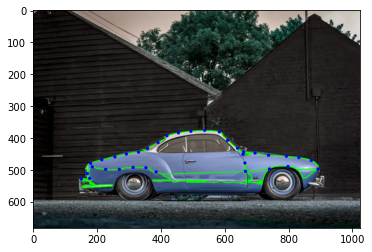

In [419]:
imagen_resultante = dibujar_contorno(imagen, contorno_superior, puntos_extrapolados)
plt.imshow(imagen_resultante)

In [420]:
puntos_extrapolados = puntos_extrapolados[puntos_extrapolados[:,0].argsort()]
h,w ,_=imagen.shape
x = puntos_extrapolados[:,0]
y = h - puntos_extrapolados[:,1]
display(x)
display(y)

array([151, 170, 177, 180, 185, 215, 227, 256, 270, 292, 313, 330, 353,
       358, 385, 391, 419, 455, 494, 537, 583, 609, 640, 657, 659, 663,
       665, 695, 737, 740, 793, 798, 832, 871, 892], dtype=int32)

array([154, 171, 156, 203, 192, 214, 184, 223, 184, 232, 190, 238, 189,
       249, 176, 268, 289, 298, 303, 306, 301, 275, 250, 231, 238, 204,
       178, 235, 228, 185, 225, 193, 221, 212, 185], dtype=int32)

In [421]:
mask = y >= 205
x_filtrado = x[mask]
y_filtrado = y[mask]
display(x_filtrado)
display(y_filtrado)
x = x_filtrado
y = y_filtrado

array([215, 256, 292, 330, 358, 391, 419, 455, 494, 537, 583, 609, 640,
       657, 659, 695, 737, 793, 832, 871], dtype=int32)

array([214, 223, 232, 238, 249, 268, 289, 298, 303, 306, 301, 275, 250,
       231, 238, 235, 228, 225, 221, 212], dtype=int32)

In [422]:
n = len(x) - 1
display(n)

19

In [423]:

h = np.diff(x)


In [424]:

delta = np.diff(y) / h


In [425]:

a = h[:-1]
b = 2 * (h[:-1] + h[1:])
c = h[1:]
d = 6 * (delta[1:] - delta[:-1])


In [426]:

m = solve_tridiagonal(a, b, c, d)
m = np.concatenate(([0], m, [0])) 

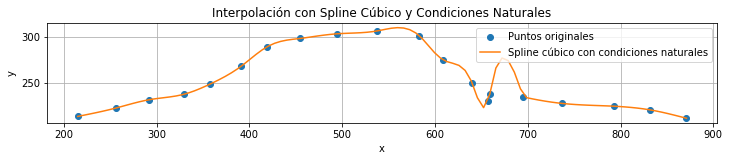

In [427]:
x_new = np.linspace(x.min(), x.max(), 100)
y_new = np.array([evaluate_spline(x, y, m, h, z) for z in x_new])
plt.figure(figsize=(12, 4)) 
plt.plot(x, y, 'o', label='Puntos originales')
plt.plot(x_new, y_new, '-', label='Spline cúbico con condiciones naturales')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolación con Spline Cúbico y Condiciones Naturales')
plt.grid(True)
plt.gca().set_aspect(1, adjustable='box')
plt.show()
